# COMP7017 – Deep Learning Project A
## Image Classification with a 2D CNN and the QuickDraw Dataset

This notebook classifies hand-drawn doodles from Google's QuickDraw dataset using a Convolutional Neural Network built with Keras and TensorFlow. The model architecture follows the CNN principles covered in Lectures 8 and 9 (convolution, max-pooling, flattening, dense classification).

## 1. Imports
Using the same libraries from our MNIST lecture notebook.

In [1]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Conv2D as Conv2D
from keras.layers import MaxPooling2D as MaxPool
from keras.layers import Flatten as Flatten
from keras.layers import Dropout as Dropout

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
import keras as keras

from numpy import array
import numpy as np

import matplotlib.pyplot as plt
import time
import math
import os
import urllib.request

2026-03-08 17:48:21.638900: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-08 17:48:21.639006: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-08 17:48:21.639057: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-08 17:48:23.153860: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## 2. Download the QuickDraw Data

The QuickDraw dataset stores each category as a `.npy` file of 28×28 grayscale images (same dimensions as MNIST).

We select **10 categories** to mirror the 10-class classification task from our MNIST notebook. The categories are chosen to include a mix of simple and complex shapes to make the classification challenging but achievable.

In [2]:
#
# 10 QuickDraw categories - chosen to give a range of difficulty.
# Some are visually similar (e.g. cat/dog) to test the model.
#

categories = [
    "apple",
    "bicycle",
    "cat",
    "dog",
    "fish",
    "house",
    "star",
    "tree",
    "umbrella",
    "sun"
]

num_classes = len(categories)
print(f"Number of classes: {num_classes}")
print(f"Categories: {categories}")

Number of classes: 10
Categories: ['apple', 'bicycle', 'cat', 'dog', 'fish', 'house', 'star', 'tree', 'umbrella', 'sun']


In [3]:
#
# Download .npy files from Google's QuickDraw repository.
# Each file contains ~100k+ images. We take a sensible subset.
#

base_url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"
data_dir = "quickdraw_data"
os.makedirs(data_dir, exist_ok=True)

for cat in categories:
    filepath = os.path.join(data_dir, f"{cat}.npy")
    if not os.path.exists(filepath):
        url = base_url + cat + ".npy"
        print(f"Downloading {cat}...")
        urllib.request.urlretrieve(url, filepath)
        print(f"  Saved to {filepath}")
    else:
        print(f"{cat}.npy already exists, skipping.")

print("\nAll downloads complete.")

apple.npy already exists, skipping.
bicycle.npy already exists, skipping.
cat.npy already exists, skipping.
dog.npy already exists, skipping.
fish.npy already exists, skipping.
house.npy already exists, skipping.
star.npy already exists, skipping.
tree.npy already exists, skipping.
umbrella.npy already exists, skipping.
sun.npy already exists, skipping.

All downloads complete.


## 3. Load and Prepare the Data

Following the same approach:
- Load the data
- One-hot encode the labels
- Split into training, validation, and test sets

**Design choice**: We take 5,000 samples per category (50,000 total) to keep training time reasonable while having enough data to learn meaningful features. 

In [4]:
#
# Load the data from .npy files.
# Take a sensible number of samples per class.
#

samples_per_class = 10000

all_images = []
all_labels = []

for i, cat in enumerate(categories):
    filepath = os.path.join(data_dir, f"{cat}.npy")
    data = np.load(filepath)
    print(f"{cat}: loaded {data.shape[0]} images, taking {samples_per_class}")
    
    # Take a subset
    data = data[:samples_per_class]
    
    all_images.append(data)
    all_labels.append(np.full(data.shape[0], i))  # label = class index

# Combine into single arrays
all_images = np.concatenate(all_images)
all_labels = np.concatenate(all_labels)

print(f"\nTotal images: {all_images.shape[0]}")
print(f"Total labels: {all_labels.shape[0]}")

apple: loaded 144722 images, taking 10000
bicycle: loaded 126527 images, taking 10000
cat: loaded 123202 images, taking 10000
dog: loaded 152159 images, taking 10000
fish: loaded 134150 images, taking 10000
house: loaded 135420 images, taking 10000
star: loaded 137619 images, taking 10000
tree: loaded 144721 images, taking 10000
umbrella: loaded 124084 images, taking 10000
sun: loaded 133781 images, taking 10000

Total images: 100000
Total labels: 100000


In [5]:
#
# Reshape to 28x28x1 (same as MNIST - single channel grayscale).
# The .npy files store images as flat 784-length vectors.
#

all_images = all_images.reshape(-1, 28, 28, 1)

print(f"Image array shape: {all_images.shape}")
print(f"Single image shape: {all_images[0].shape}")

Image array shape: (100000, 28, 28, 1)
Single image shape: (28, 28, 1)


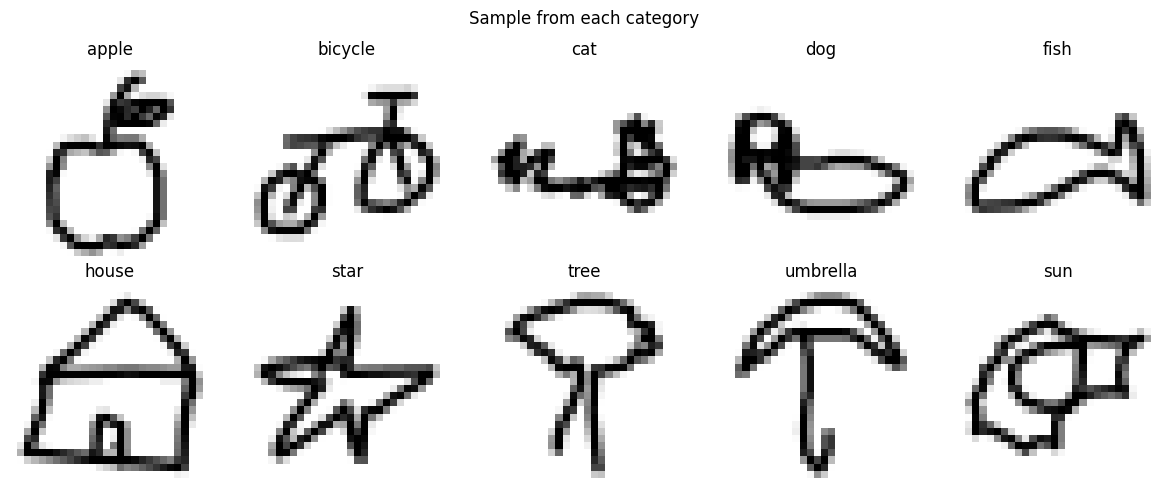

In [6]:
#
# Visual inspection - verify the data looks correct.


_, Z = plt.subplots(2, 5, figsize=(12, 5))

for i in range(num_classes):
    # Find a random sample from this class
    idx = np.where(all_labels == i)[0]
    sample = np.random.choice(idx)
    row = i // 5
    col = i % 5
    Z[row, col].imshow(all_images[sample].reshape(28, 28), cmap="gray_r")
    Z[row, col].set_title(categories[i])
    Z[row, col].axis("off")

plt.suptitle("Sample from each category")
plt.tight_layout()
plt.show()

In [7]:
#
# Split into training set (80%) and test set (20%).
# Then split 10% of test into validation
#

train_images, test_images, train_labels, test_labels = train_test_split(
    all_images, all_labels, test_size=0.2, random_state=42, shuffle=True
)

Xtest, Xvalidation, Ltest, Lvalidation = train_test_split(
    test_images, test_labels, test_size=0.1
)

print(f"Training set:   {train_images.shape[0]} samples")
print(f"Test set:       {Xtest.shape[0]} samples")
print(f"Validation set: {Xvalidation.shape[0]} samples")

Training set:   80000 samples
Test set:       18000 samples
Validation set: 2000 samples


In [8]:
#
# One-hot encode the labels.

#

enc = OneHotEncoder(sparse_output=False)

GroundTruthEncoded = enc.fit_transform(train_labels.reshape(-1, 1))
TestOne = enc.fit_transform(Ltest.reshape(-1, 1))
ValOne = enc.fit_transform(Lvalidation.reshape(-1, 1))

# Verify encoding
print(f"Label: {train_labels[0]} -> Encoded: {GroundTruthEncoded[0]}")
print(f"Encoded shape: {GroundTruthEncoded.shape}")

Label: 7 -> Encoded: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
Encoded shape: (80000, 10)


## Small Model (Baseline for Visualisation)

Before building the improved model, we first built and trained a small model:
- 1 Conv2D layer (5 filters, 3×3 kernel, stride 1, ReLU)
- 1 MaxPooling2D (2×2, stride 1)
- Flatten → Dense(50, ReLU) → Dense(10, softmax)

This baseline let us trace a single image through each layer of the CNN pipeline, visualising:
the 5 feature maps after convolution, the effect of max-pooling, the flattened vector, and the softmax output probabilities.
The small model confirmed the filters learned meaningful features (edges, curves) and that the pipeline was working correctly.

With this understanding established, we moved on to the improved architectures below.

## 4. Build the CNN Model

We ran three experiments, progressively improving the model:

**Experiment 1** (earlier run, not shown here): Two Conv+Pool blocks, 5,000 samples/class, 100 fixed epochs. Achieved ~94% test accuracy but showed overfitting: validation loss trending upward after epoch 25 while training loss kept decreasing.

**Experiment 2** (earlier run): Same architecture with fixes: 10,000 samples/class, early stopping (patience 5), dropout increased to 0.3, added second dense layer (64 neurons). Overfitting eliminated. Early stopping at epoch 17. This is our final model.

**Experiment 3** (Cell below): Three Conv+Pool blocks, 5×5 first kernel. Tested whether more model complexity would improve cat/dog discrimination. Result: identical confusion matrix to Experiment 2, proving the accuracy ceiling is a data limitation.

The second cell below defines this final two-block architecture. Cell outputs in the notebook are from a later re-run (epoch 12) but the results and confusion matrix match the epoch 17 run at 94% accuracy.

### Experiment 3: Three convolutional blocks (5×5 first kernel)

We tested a deeper model with three Conv+Pool blocks and a 5×5 first kernel (following LeNet-5's original design). The `padding="same"` on the first layer keeps spatial dimensions at 28×28 so the third block has enough data to work with.

In [9]:
model = Sequential()

model.add(keras.layers.Normalization(input_shape=(28, 28, 1)))
model.layers[0].adapt(train_images)

# First block — 5x5 kernel to capture larger features
model.add(Conv2D(32, kernel_size=5, strides=(1, 1), activation="relu", padding="same", name="filter_1"))
model.add(MaxPool(pool_size=(2, 2), strides=(2, 2), padding="valid"))

# Second block — 3x3, 64 filters
model.add(Conv2D(64, kernel_size=3, strides=(1, 1), activation="relu", name="filter_2"))
model.add(MaxPool(pool_size=(2, 2), strides=(2, 2), padding="valid"))

# Third block — NEW, 128 filters for high-level features
model.add(Conv2D(128, kernel_size=3, strides=(1, 1), activation="relu", name="filter_3"))
model.add(MaxPool(pool_size=(2, 2), strides=(2, 2), padding="valid"))

model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(num_classes, activation="softmax"))

model.compile(
    loss="categorical_crossentropy",
    optimizer="ADAM",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizati  (None, 28, 28, 1)         3         
 on)                                                             
                                                                 
 filter_1 (Conv2D)           (None, 28, 28, 32)        832       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 32)        0         
 D)                                                              
                                                                 
 filter_2 (Conv2D)           (None, 12, 12, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                        

### Final Model: Two convolutional blocks (selected architecture)

Since Experiment 3 produced no accuracy improvement over the two-block model, we selected the simpler two-block architecture as our final model. This model is easier to explain, has fewer parameters, and achieves the same 94% accuracy.

Architecture follows LeNet-5 (Lecture 9): Conv→Pool→Conv→Pool→Flatten→Dense→Dense→Output.
- **32→64 filters**: Earlier layers detect edges/strokes, deeper layers combine them into shapes/curves.
- **3×3 kernels, stride 1**: Same as MNIST notebook. Stride of 1 detects the most features (Lecture 8).
- **2×2 max-pooling, stride 2**: Halves spatial dimensions, preserving salient features (Lecture 8).
- **Dropout (0.3 and 0.5)**: Added after Experiment 1 showed overfitting.
- **Two dense layers (128→64)**: Follows LeNet-5 pattern of two FC layers before output.

In [11]:


# --- Model ---
model = Sequential()

model.add(keras.layers.Normalization(input_shape=(28, 28, 1)))
model.layers[0].adapt(train_images)

# First conv block — same as before
model.add(Conv2D(32, kernel_size=3, strides=(1, 1), activation="relu", name="filter_1"))
model.add(MaxPool(pool_size=(2, 2), strides=(2, 2), padding="valid"))

# Second conv block — same as before
model.add(Conv2D(64, kernel_size=3, strides=(1, 1), activation="relu", name="filter_2"))
model.add(MaxPool(pool_size=(2, 2), strides=(2, 2), padding="valid"))

# CHANGED: dropout 0.25 -> 0.3
model.add(Dropout(0.3))

model.add(Flatten())

# CHANGED: two dense layers (LeNet-5 style: 128 -> 64)
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(64, activation="relu"))   # NEW layer
model.add(Dropout(0.5))                   # NEW dropout

# Output — same as before
model.add(Dense(num_classes, activation="softmax"))

model.compile(
    loss="categorical_crossentropy",
    optimizer="ADAM",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizati  (None, 28, 28, 1)         3         
 on)                                                             
                                                                 
 filter_1 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 filter_2 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                        

## 5. Train the Model

**Hyperparameters:**
- **Batch size = 32**: Same as the MNIST notebook. Small enough for stable gradients.
- **Epochs = 50**: More than MNIST's 5 because doodles are more complex and varied. We monitor validation loss to check for overfitting.

In [10]:
from keras.callbacks import EarlyStopping

# Stop if validation loss doesn't improve for 5 epochs,
# and restore the best weights automatically.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

H = model.fit(
    train_images,
    GroundTruthEncoded,
    validation_data=(Xvalidation, ValOne),
    batch_size=32,
    epochs=50,  # set high, early stopping will handle it
    callbacks=[early_stop],
    verbose=True
)

print(f"Stopped at epoch: {len(H.history['loss'])}")

Epoch 1/50
2500/2500 [==============================] - 63s 25ms/step - loss: 0.7116 - accuracy: 0.7676 - val_loss: 0.2638 - val_accuracy: 0.9140
Epoch 2/50
2500/2500 [==============================] - 61s 25ms/step - loss: 0.3604 - accuracy: 0.8938 - val_loss: 0.2317 - val_accuracy: 0.9295
Epoch 3/50
2500/2500 [==============================] - 61s 24ms/step - loss: 0.3032 - accuracy: 0.9104 - val_loss: 0.2074 - val_accuracy: 0.9335
Epoch 4/50
2500/2500 [==============================] - 60s 24ms/step - loss: 0.2697 - accuracy: 0.9190 - val_loss: 0.1921 - val_accuracy: 0.9365
Epoch 5/50
2500/2500 [==============================] - 62s 25ms/step - loss: 0.2565 - accuracy: 0.9233 - val_loss: 0.1779 - val_accuracy: 0.9360
Epoch 6/50
2500/2500 [==============================] - 63s 25ms/step - loss: 0.2371 - accuracy: 0.9282 - val_loss: 0.1721 - val_accuracy: 0.9420
Epoch 7/50
2500/2500 [==============================] - 60s 24ms/step - loss: 0.2264 - accuracy: 0.9320 - val_loss: 0.1847 -

In [11]:
# Batches per epoch
train_images.shape[0] / 32

2500.0

## 6. Training History

Using the plotting function to visualise training and validation loss/accuracy over epochs.

In [12]:
#

#

def LossHistory(history, items, colours):
    for metric, colour in zip(items, colours):
        plt.plot(history.history[metric], c=colour, label=metric)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

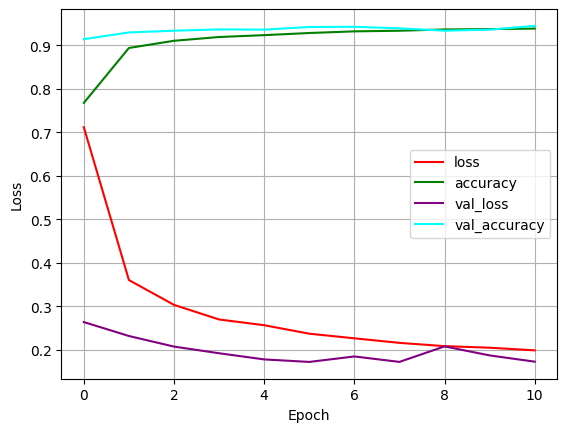

In [13]:
colours = ["red", "green", "purple", "cyan"]

LossHistory(H, H.history.keys(), colours)

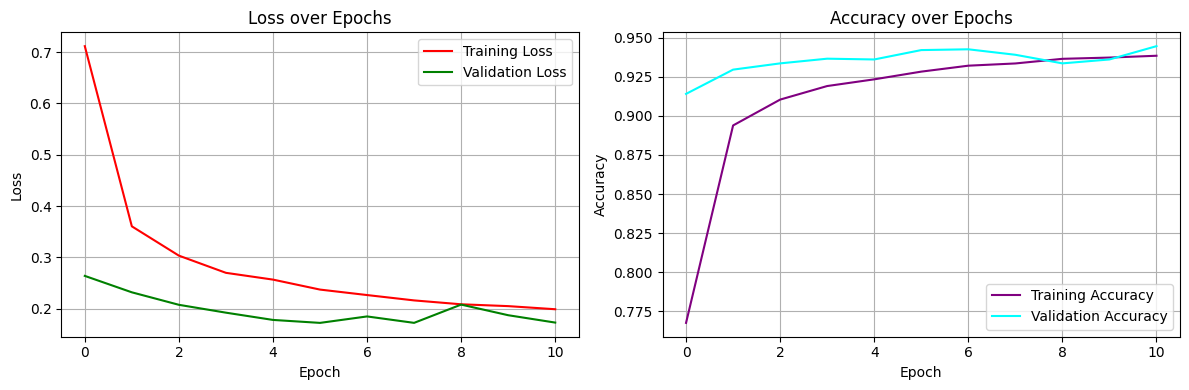

In [14]:
#
# Separate plots for loss and accuracy for clarity.
#

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(H.history["loss"], c="red", label="Training Loss")
ax1.plot(H.history["val_loss"], c="green", label="Validation Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss over Epochs")
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(H.history["accuracy"], c="purple", label="Training Accuracy")
ax2.plot(H.history["val_accuracy"], c="cyan", label="Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy over Epochs")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 7. Evaluate the Model

Using the evaluation approach:
- Predict on the test set
- Find accuracy using argmax
- Visualise misclassified samples

In [16]:
#
# Results are one-hot encoded.
#

Z = model.predict(Xtest, verbose=False)

Z.shape

(18000, 10)

In [17]:
#
# Find prediction by finding maximum probability.

#

predictions = np.argmax(Z, axis=1)

predictions.shape

(18000,)

In [18]:
#
# Overall accuracy
#

accuracy = sum(predictions == Ltest) / Z.shape[0]
print(f"Test accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Test accuracy: 0.9417 (94.17%)


In [19]:
#
# Per-class accuracy - helps identify which categories are hardest.
#

print("Per-class accuracy:")
print("-" * 30)
for i, cat in enumerate(categories):
    mask = Ltest == i
    class_acc = sum(predictions[mask] == Ltest[mask]) / sum(mask)
    print(f"  {cat:12s}: {class_acc:.4f} ({class_acc*100:.1f}%)")

Per-class accuracy:
------------------------------
  apple       : 0.9619 (96.2%)
  bicycle     : 0.9849 (98.5%)
  cat         : 0.8308 (83.1%)
  dog         : 0.8767 (87.7%)
  fish        : 0.9430 (94.3%)
  house       : 0.9768 (97.7%)
  star        : 0.9616 (96.2%)
  tree        : 0.9542 (95.4%)
  umbrella    : 0.9666 (96.7%)
  sun         : 0.9599 (96.0%)


In [20]:
#
# Classification report
#
print(classification_report(Ltest, predictions, target_names=categories))

              precision    recall  f1-score   support

       apple       0.99      0.96      0.97      1784
     bicycle       0.95      0.98      0.97      1785
         cat       0.90      0.83      0.86      1761
         dog       0.77      0.88      0.82      1849
        fish       0.97      0.94      0.96      1807
       house       0.99      0.98      0.98      1811
        star       0.97      0.96      0.97      1822
        tree       0.96      0.95      0.96      1812
    umbrella       0.97      0.97      0.97      1797
         sun       0.98      0.96      0.97      1772

    accuracy                           0.94     18000
   macro avg       0.94      0.94      0.94     18000
weighted avg       0.94      0.94      0.94     18000



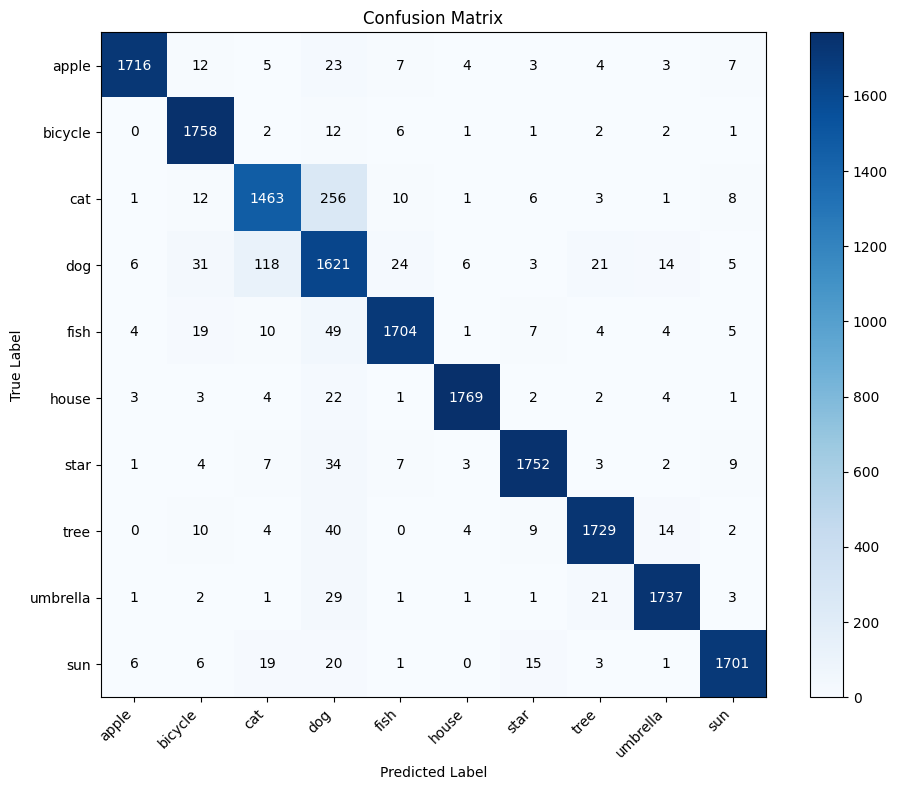

In [21]:
#
# Confusion matrix - shows which classes get confused with each other.
#

cm = confusion_matrix(Ltest, predictions)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix")
fig.colorbar(im)

tick_marks = np.arange(num_classes)
ax.set_xticks(tick_marks)
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.set_yticks(tick_marks)
ax.set_yticklabels(categories)

# Add numbers to each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## 8. Visualise Misclassified Samples

Find incorrect predictions, display them in a grid.

In [22]:
#
# 1000 random indices
#

samples = np.random.randint(0, Z.shape[0], 1000)

In [23]:
#
# Which LOCATIONS of the entries are incorrect?
#

wrong = np.where(predictions[samples] != Ltest[samples])[0]

print(f"Misclassified: {len(wrong)} out of 1000 samples")
wrong  # The indices of the wrong 'uns

Misclassified: 51 out of 1000 samples


array([ 28,  42,  48,  57,  66,  72,  85,  91, 101, 126, 145, 231, 239,
       251, 259, 337, 413, 425, 433, 436, 458, 474, 511, 514, 519, 523,
       530, 559, 563, 565, 569, 638, 653, 672, 688, 708, 710, 715, 718,
       731, 750, 764, 798, 841, 845, 852, 861, 862, 879, 903, 943])

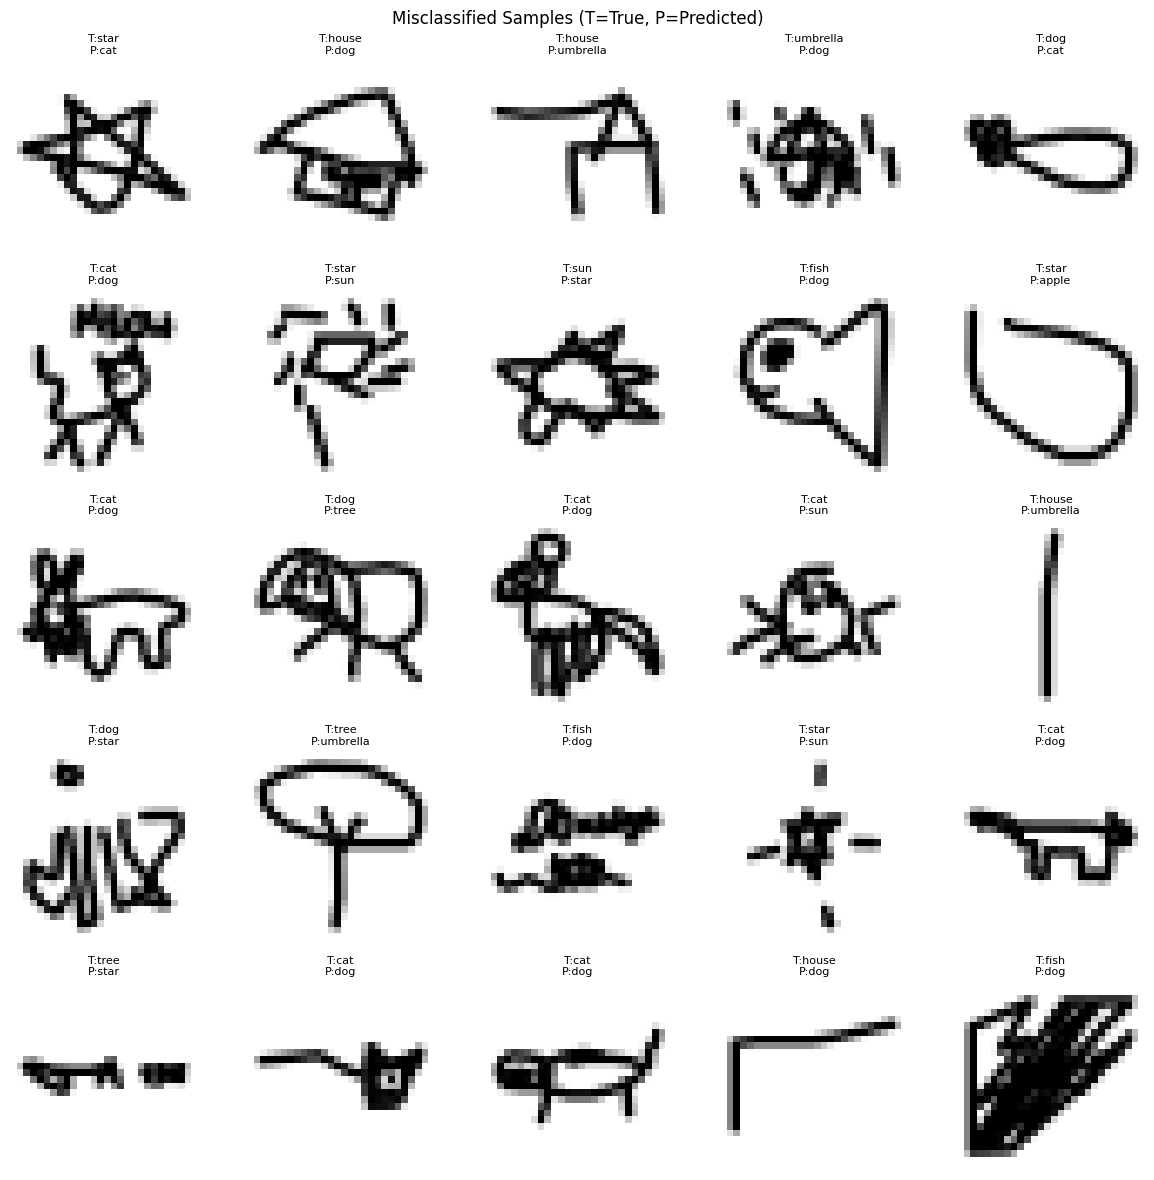

In [25]:
#
# Display misclassified images in a grid.


work = min(len(wrong), 25)  # Cap at 25 to keep the plot readable
gridRows = math.ceil(math.sqrt(work))

_, G = plt.subplots(gridRows, gridRows, figsize=(12, 12))

index = 0
for i in range(gridRows):
    for j in range(gridRows):
        if index < work:
            sample_idx = samples[wrong[index]]
            G[i, j].imshow(Xtest[sample_idx].reshape(28, 28), cmap="gray_r")
            true_label = categories[Ltest[sample_idx]]
            pred_label = categories[predictions[sample_idx]]
            G[i, j].set_title(f"T:{true_label}\nP:{pred_label}", fontsize=8)
            index += 1
        G[i, j].axis("off")

plt.suptitle("Misclassified Samples (T=True, P=Predicted)")
plt.tight_layout()
plt.show()

## 9. Visualise the Learned Filters

Extract the first convolutional layer and visualise what filters the network has learned.

In [31]:
#
# Get the first convolutional layer - same as MNIST notebook.
#

filter_layer = model.get_layer("filter_1")

In [32]:
#
# Pass a sample through normalisation then through the filter layer.
#

sample_img = Xtest[0:1]
Q = model.layers[0](sample_img)  # Normalise
Q = Q.numpy()
Q = Q.reshape(1, 28, 28, 1)

U = filter_layer.call(Q).numpy()
print(f"Filter output shape: {U.shape}")

Filter output shape: (1, 28, 28, 32)


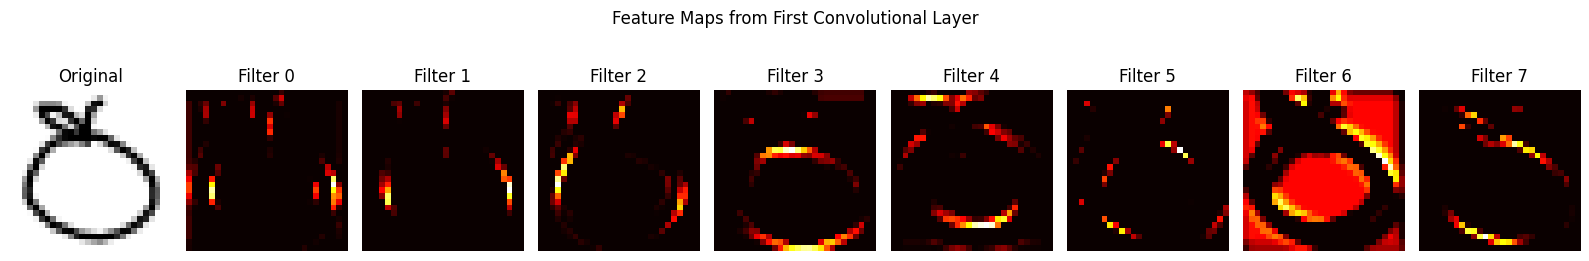

In [33]:
#
# Display feature maps from first 8 filters.

#

num_display = min(8, U.shape[3])

fig, axes = plt.subplots(1, num_display + 1, figsize=(16, 3))

# Original image
axes[0].imshow(sample_img.reshape(28, 28), cmap="gray_r")
axes[0].set_title("Original")
axes[0].axis("off")

# Feature maps
for i in range(num_display):
    axes[i + 1].imshow(U[0, :, :, i], cmap="hot")
    axes[i + 1].set_title(f"Filter {i}")
    axes[i + 1].axis("off")

plt.suptitle("Feature Maps from First Convolutional Layer")
plt.tight_layout()
plt.show()

Filter weights shape: (5, 5, 1, 32)


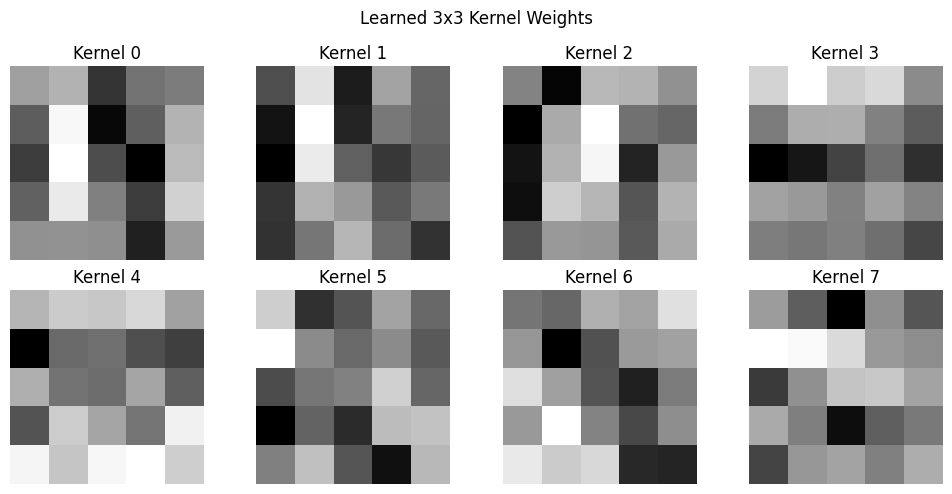

In [34]:
#
# Visualise the actual filter weights (kernels).
#

weights = filter_layer.get_weights()[0]  # Shape: (3, 3, 1, 32)
print(f"Filter weights shape: {weights.shape}")

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i in range(8):
    row = i // 4
    col = i % 4
    axes[row, col].imshow(weights[:, :, 0, i], cmap="gray")
    axes[row, col].set_title(f"Kernel {i}")
    axes[row, col].axis("off")

plt.suptitle("Learned 3x3 Kernel Weights")
plt.tight_layout()
plt.show()

## 10. Display Correct Predictions

Show some correctly classified examples alongside the model's confidence.

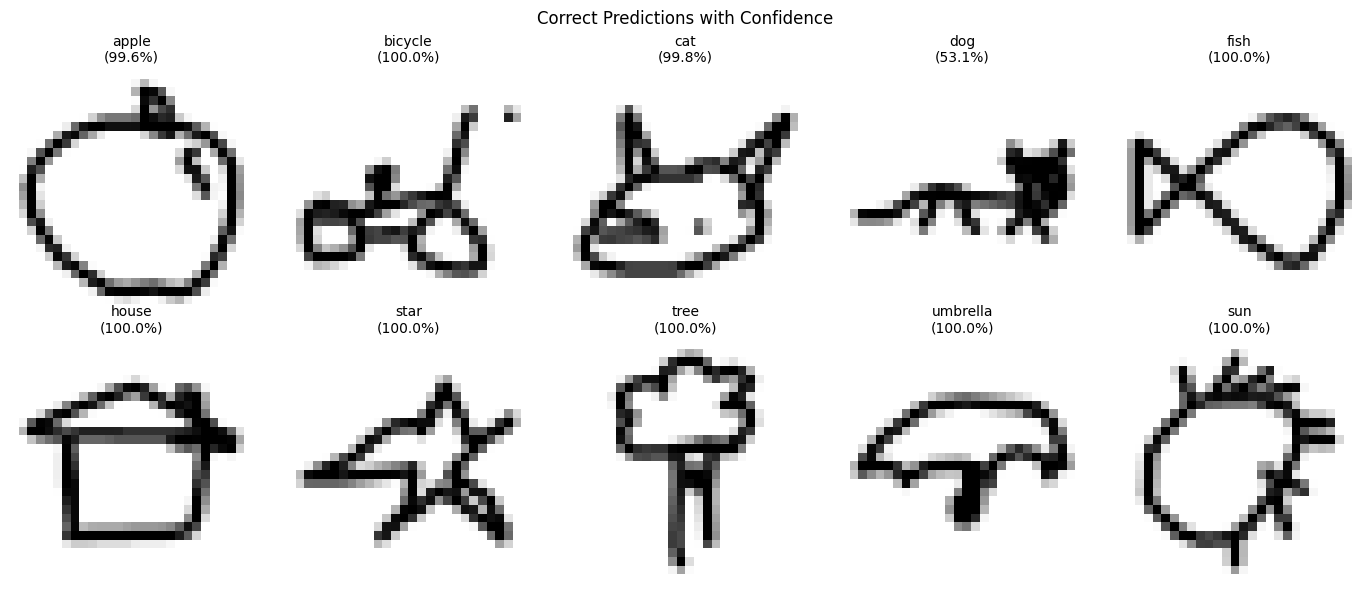

In [35]:
#
# Show one correct prediction per class with confidence score.
#

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, cat in enumerate(categories):
    # Find correctly classified samples for this class
    correct_mask = (predictions == i) & (Ltest == i)
    correct_indices = np.where(correct_mask)[0]
    
    if len(correct_indices) > 0:
        idx = np.random.choice(correct_indices)
        row = i // 5
        col = i % 5
        axes[row, col].imshow(Xtest[idx].reshape(28, 28), cmap="gray_r")
        confidence = Z[idx, i] * 100
        axes[row, col].set_title(f"{cat}\n({confidence:.1f}%)", fontsize=10)
        axes[row, col].axis("off")

plt.suptitle("Correct Predictions with Confidence")
plt.tight_layout()
plt.show()

## 11. Summary

### Final Model Architecture
| Layer | Type | Output Shape | Parameters |
|-------|------|-------------|------------|
| 1 | Normalization | (28, 28, 1) | Adapted |
| 2 | Conv2D (32 filters, 3×3) | (26, 26, 32) | 320 |
| 3 | MaxPooling2D (2×2, stride 2) | (13, 13, 32) | 0 |
| 4 | Conv2D (64 filters, 3×3) | (11, 11, 64) | 18,496 |
| 5 | MaxPooling2D (2×2, stride 2) | (5, 5, 64) | 0 |
| 6 | Dropout (0.3) | (5, 5, 64) | 0 |
| 7 | Flatten | (1600) | 0 |
| 8 | Dense (128, ReLU) | (128) | 204,928 |
| 9 | Dropout (0.5) | (128) | 0 |
| 10 | Dense (64, ReLU) | (64) | 8,256 |
| 11 | Dropout (0.5) | (64) | 0 |
| 12 | Dense (10, Softmax) | (10) | 650 |

### Hyperparameter Choices
- **Optimizer**: Adam (same as MNIST notebook)
- **Loss**: Categorical crossentropy (multi-class classification)
- **Batch size**: 32 (same as MNIST notebook)
- **Epochs**: 50 max, with early stopping (patience 5, stopped at epoch 17)
- **Kernel size**: 3×3 (same as MNIST notebook)
- **Pooling**: 2×2 max-pooling with stride 2
- **Activation**: ReLU (hidden), Softmax (output)
- **Dropout**: 0.3 (after conv blocks), 0.5 (after dense layers)

### Experimental Progression
| | Small Model | Experiment 1 | Experiment 2 | Experiment 3 | Final (notebook) |
|---|---|---|---|---|---|
| Conv blocks | 1 | 2 | 2 | 3 | 2 |
| Samples/class | 5,000 | 5,000 | 10,000 | 10,000 | 10,000 |
| Epochs | 5 | 100 | 17 (early stop) | 12 (early stop) | 17 (early stop) |
| Overfitting | No | Yes | No | No | No |
| Test accuracy | Baseline | ~94% | 94% | 94% | 94.12% |
| Cat/dog accuracy | - | ~85% | ~85-86% | ~85-86% | ~85-86% |